# Natural Disasters File Cleaning
---

## Table of Contents
1. [Load Data](#1-load-data)
2. [Select Columns](#2-select-columns)
3. [Data Validation](#3-data-validation)
4. [Duration Analysis](#4-duration-analysis)
5. [Outlier Investigation & Fix](#5-outlier-investigation--fix)
6. [Date Imputation](#6-date-imputation)
7. [Impact Column Imputation](#7-impact-column-imputation)
8. [Finalise Dataset](#8-finalise-dataset)
9. [Feature Engineering](#9-feature-engineering)
10. [Final Dataset Preview](#10-final-dataset-preview)
11. [National Disaster Profile per Country](#11-national-disaster-profile-per-country)
12. [National Disaster Profile Preview](#12-national-disaster-profile-preview)
13. [Multivariate Assessment for Index Integration](#13-multivariate-assessment-for-index-integration)
14. [Data Source](#14-data-source)
15. [References](#15-references)

## 1. Load Data
The raw dataset is loaded from the EMDAT Excel file and the first 10 rows are displayed to get a feel for the data and its structure.

In [1]:
# Importing the Natural Disasters Excel file and displaying the first 10 rows of the dataset.
import pandas as pd
pd.set_option('display.max_columns', None)
natural_disasters = pd.read_excel('../Raw_Csvs/Natural_Disasters2023.xlsx')
natural_disasters.head(10)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2023-0193-COD,No,nat-hyd-mmw-lan,Natural,Hydrological,Mass movement (wet),Landslide (wet),GLIDE:FL-2023-000060,NaN,COD,Democratic Republic of the Congo,Sub-Saharan Africa,Africa,"Bulwa (Masisi, Nord-Kivu)",Heavy rains,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,2023,4.0,2.0,2023,4.0,2.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,"[{""adm1_code"":1074,""adm1_name"":""Nord-Kivu""}]","[{""gid_1"":""COD.19_1"",""migration_date"":""2025-12...",2023-04-03,2025-12-20
1,2023-0844-AGO,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2023-000249,NaN,AGO,Angola,Sub-Saharan Africa,Africa,"Luanda, Huambo, Bie, Malanje and Kwanza Norte ...",Heavy rains,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2023,11.0,30.0,2023,12.0,5.0,30.0,NaN,116275.0,NaN,116275.0,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_1"":""AGO.11_1"",""name_1"":""Luanda""},{""gid_...",2023-12-19,2026-01-16
2,2023-0854-THA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,THA,Thailand,South-eastern Asia,Asia,"Satun, Songkhla, Pattani,, Yala, Narathiwat pr...",Heavy rains,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2023,12.0,22.0,2023,12.0,25.0,6.0,NaN,241473.0,NaN,241473.0,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_1"":""THA.33_1"",""name_1"":""Narathiwat""},{""...",2024-01-02,2026-01-16
3,2023-0857-COD,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,COD,Democratic Republic of the Congo,Sub-Saharan Africa,Africa,"Bukavu, and Burhinyi (South Kivu)",Heavy rains,"Slide (land, mud, snow, rock)",No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2023,12.0,26.0,2023,12.0,27.0,40.0,5.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_2"":""COD.22.2_1"",""name_2"":""Bukavu""},{""gi...",2024-01-02,2026-01-16
4,2023-0866-FRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2023-000258,NaN,FRA,France,Western Europe,Europe,Nord and Pas-de-Calais departments,Heavy rains,Storm,No,No,No,NaN,NaN,Km2,NaN,NaN,"Aa, Helpe Mineure and Solre rivers",2023,12.0,30.0,2024,1.0,3.0,1.0,2.0,6048.0,NaN,6050.0,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_2"":""FRA.7.2_1"",""name_2"":""Nord""},{""gid_2...",2024-01-04,2026-01-16
5,2023-0846-IND,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,IND,India,Southern Asia,Asia,"Thoothukudi, Tirunelveli, Kanniyakumari and Te...",Heavy rains,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2023,12.0,18.0,2023,12.0,20.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_2"":""IND.31.25_1"",""name_2"":""Thoothukkudi...",2023-12-21,2026-01-16
6,2023-0854-MYS,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,MYS,Malaysia,South-eastern Asia,Asia,"Johor, Kelantan, Pahang, Sabah, and Terengganu...",Heavy rains,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2023,12.0,22.0,2023,12.0,25.0,2.0,NaN,25676.0,NaN,25676.0,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_1"":""MYS.13_1"",""name_1"":""Sabah""},{""gid_1...",2024-01-02,2026-01-16
7,2023-0855-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,South Africa,Sub-Saharan Africa,Africa,"Ladysmith, Mandeni (KwaZulu-Natal province)",Heavy rains,"Slide (land, mud, snow, rock)",No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2023,12.0,24.0,2023,12.0,26.0,34.0,NaN,1800.0,NaN,1800.0,NaN,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_2"

## 2. Select Columns
Only the columns relevant to the analysis are retained.

In [2]:
# Keeping only the columns that I want to use for the analysis.
natural_disasters_cols = ['Disaster Type', 'Country', 'Start Month', 'Start Day', 'End Month', 'End Day', 'Total Affected', 'No. Injured', 'No. Affected', 'No. Homeless']
natural_disasters_clean = natural_disasters
natural_disasters_clean = natural_disasters_clean[natural_disasters_cols].copy()
natural_disasters_clean.head(10)


,Disaster Type,Country,Start Month,Start Day,End Month,End Day,Total Affected,No. Injured,No. Affected,No. Homeless
0,Mass movement (wet),Democratic Republic of the Congo,4.0,2.0,4.0,2.0,NaN,NaN,NaN,NaN
1,Flood,Angola,11.0,30.0,12.0,5.0,116275.0,NaN,116275.0,NaN
2,Flood,Thailand,12.0,22.0,12.0,25.0,241473.0,NaN,241473.0,NaN
3,Flood,Democratic Republic of the Congo,12.0,26.0,12.0,27.0,5.0,5.0,NaN,NaN
4,Flood,France,12.0,30.0,1.0,3.0,6050.0,2.0,6048.0,NaN
5,Flood,India,12.0,18.0,12.0,20.0,NaN,NaN,NaN,NaN
6,Flood,Malaysia,12.0,22.0,12.0,25.0,25676.0,NaN,25676.0,NaN
7,Flood,South Africa,12.0,24.0,12.0,26.0,1800.0,NaN,1800.0,NaN
8,Flood,Congo,12.0,7.0,1.0,15.0,1800000.0,NaN,1800000.0,NaN
9,Rail,Greece,3.0,1.0,3.0,1.0,180.0,180.0,NaN,NaN


## 3. Data Validation
Unique disaster types are listed and each column is checked for missing or blank values before any transformations are applied.

In [3]:
print("Unique Disaster Types:")
print(natural_disasters_clean['Disaster Type'].unique())

Unique Disaster Types:
<StringArray>
[             'Mass movement (wet)',                            'Flood',
                             'Rail',                'Volcanic activity',
                       'Earthquake',                         'Epidemic',
                            'Storm',                            'Water',
             'Fire (Miscellaneous)',                              'Air',
                             'Road', 'Miscellaneous accident (General)',
         'Collapse (Miscellaneous)',              'Extreme temperature',
            'Collapse (Industrial)',           'Explosion (Industrial)',
                'Fire (Industrial)',        'Explosion (Miscellaneous)',
                         'Wildfire',                         'Gas leak',
      'Glacial lake outburst flood',    'Industrial accident (General)',
                          'Drought']
Length: 23, dtype: str


In [4]:
# Check every column for missing or blank values
print("Missing value counts per column:")
print("-" * 40)
print(f"Country:              {natural_disasters_clean['Country'].isna().sum()} NaN  |  {(natural_disasters_clean['Country'] == '').sum()} blank")
print(f"Disaster Type:        {natural_disasters_clean['Disaster Type'].isna().sum()} NaN  |  {(natural_disasters_clean['Disaster Type'] == '').sum()} blank")
print(f"Start Month:          {natural_disasters_clean['Start Month'].isna().sum()} NaN  |  {(natural_disasters_clean['Start Month'] == '').sum()} blank")
print(f"Start Day:            {natural_disasters_clean['Start Day'].isna().sum()} NaN  |  {(natural_disasters_clean['Start Day'] == '').sum()} blank")
print(f"End Month:            {natural_disasters_clean['End Month'].isna().sum()} NaN  |  {(natural_disasters_clean['End Month'] == '').sum()} blank")
print(f"End Day:              {natural_disasters_clean['End Day'].isna().sum()} NaN  |  {(natural_disasters_clean['End Day'] == '').sum()} blank")
print(f"No. Injured:          {natural_disasters_clean['No. Injured'].isna().sum()} NaN  |  {(natural_disasters_clean['No. Injured'] == '').sum()} blank")
print(f"No. Affected:         {natural_disasters_clean['No. Affected'].isna().sum()} NaN  |  {(natural_disasters_clean['No. Affected'] == '').sum()} blank")
print(f"No. Homeless:         {natural_disasters_clean['No. Homeless'].isna().sum()} NaN  |  {(natural_disasters_clean['No. Homeless'] == '').sum()} blank")
print(f"Total Affected:       {natural_disasters_clean['Total Affected'].isna().sum()} NaN  |  {(natural_disasters_clean['Total Affected'] == '').sum()} blank")


Missing value counts per column:
----------------------------------------
Country:              0 NaN  |  0 blank
Disaster Type:        0 NaN  |  0 blank
Start Month:          5 NaN  |  0 blank
Start Day:            74 NaN  |  0 blank
End Month:            6 NaN  |  0 blank
End Day:              66 NaN  |  0 blank
No. Injured:          371 NaN  |  0 blank
No. Affected:         300 NaN  |  0 blank
No. Homeless:         592 NaN  |  0 blank
Total Affected:       168 NaN  |  0 blank


## 4. Duration Analysis
Temporary start and end date columns are constructed to calculate event duration in days. I then use Box plots and the IQR method to identify outliers per disaster type.

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta

REFERENCE_YEAR = 2023

def safe_date(month, day, year=REFERENCE_YEAR):
    # Safely construct a date object; returns None on invalid/missing inputs.
    try:
        return date(year, int(month), int(day))
    except (ValueError, TypeError):
        return None

df = natural_disasters_clean.copy()

# Build temporary date columns for duration calculation
df['_start_date'] = df.apply(
    lambda r: safe_date(r['Start Month'], r['Start Day'])
              if pd.notna(r['Start Month']) and pd.notna(r['Start Day']) else None,
    axis=1
)
df['_end_date'] = df.apply(
    lambda r: safe_date(r['End Month'], r['End Day'])
              if pd.notna(r['End Month']) and pd.notna(r['End Day']) else None,
    axis=1
)

YEAR_END = date(REFERENCE_YEAR, 12, 31)

def calc_duration(row):
    # Returns duration in days between start and end dates.
    # If the end date is earlier in the calendar than the start (i.e. the disaster
    # spans a year-end boundary), the end date is capped at Dec 31 of the reference
    # year rather than rolling into the next year.
    # Minimum duration is 1 day (same-day events are treated as lasting 1 day).

    s, e = row['_start_date'], row['_end_date']
    if s is None or e is None:
        return np.nan
    delta = (e - s).days
    if delta < 0:
        # cap end at last day of the reference year
        e = YEAR_END
        delta = (e - s).days
    return max(delta, 1)

df['_duration'] = df.apply(calc_duration, axis=1)


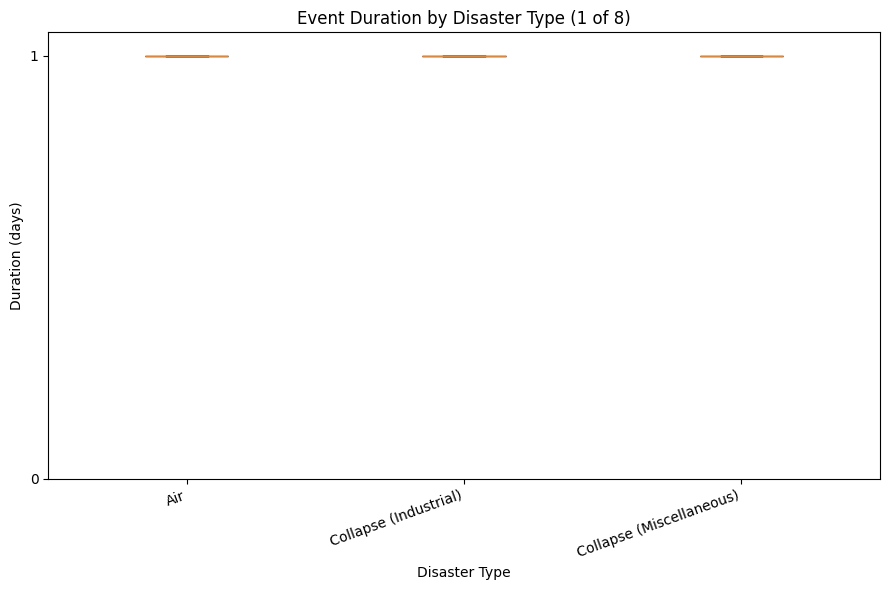

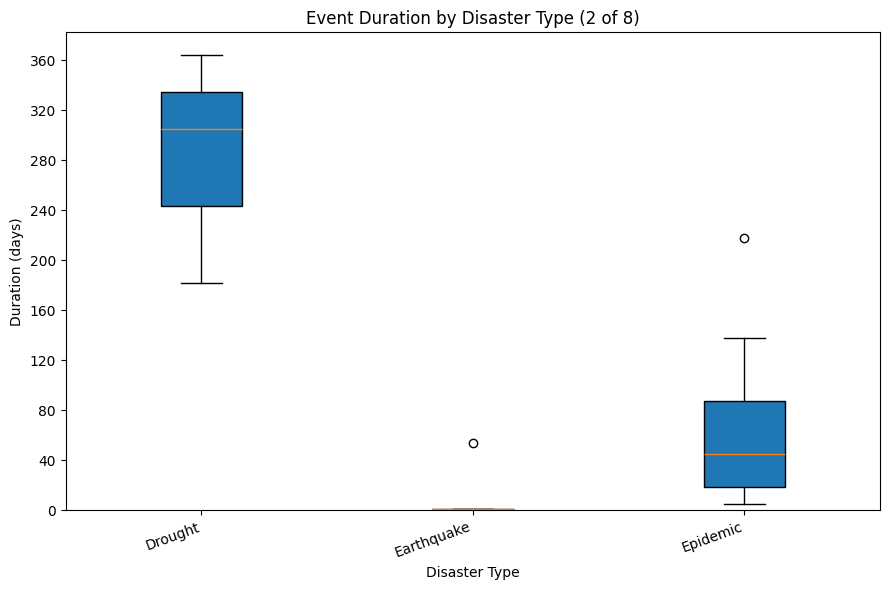

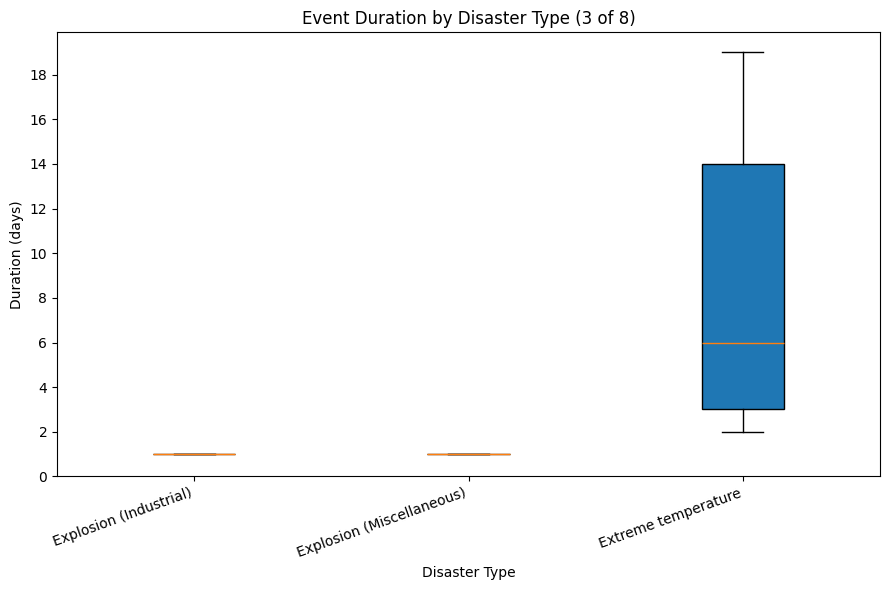

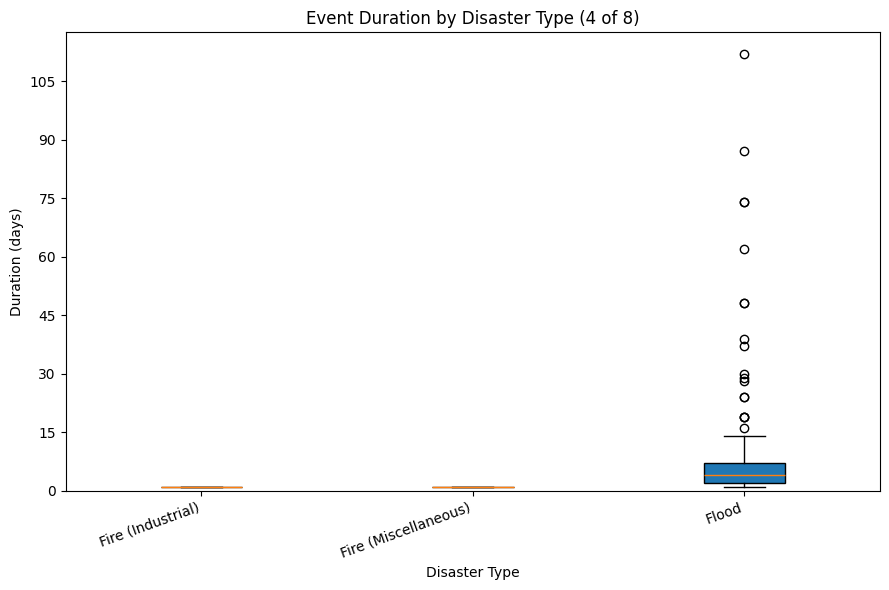

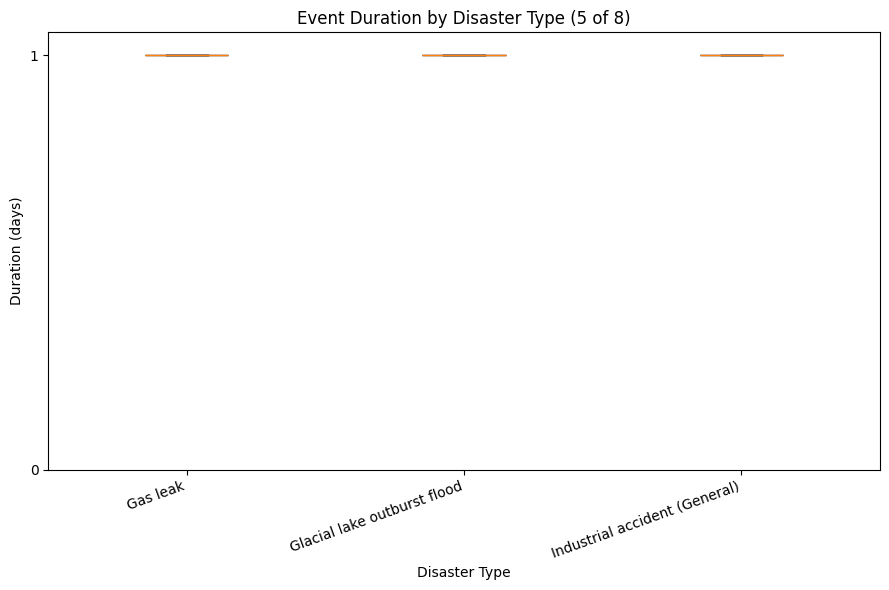

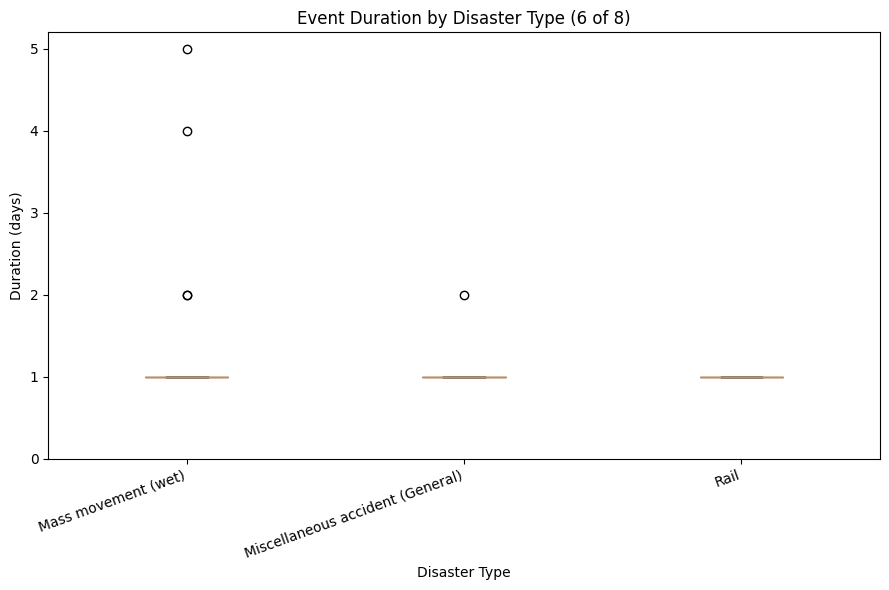

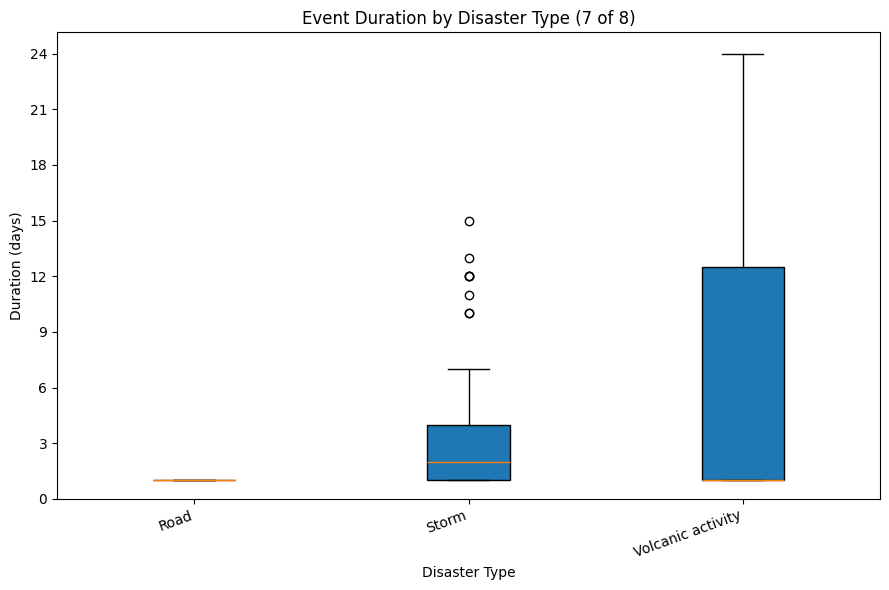

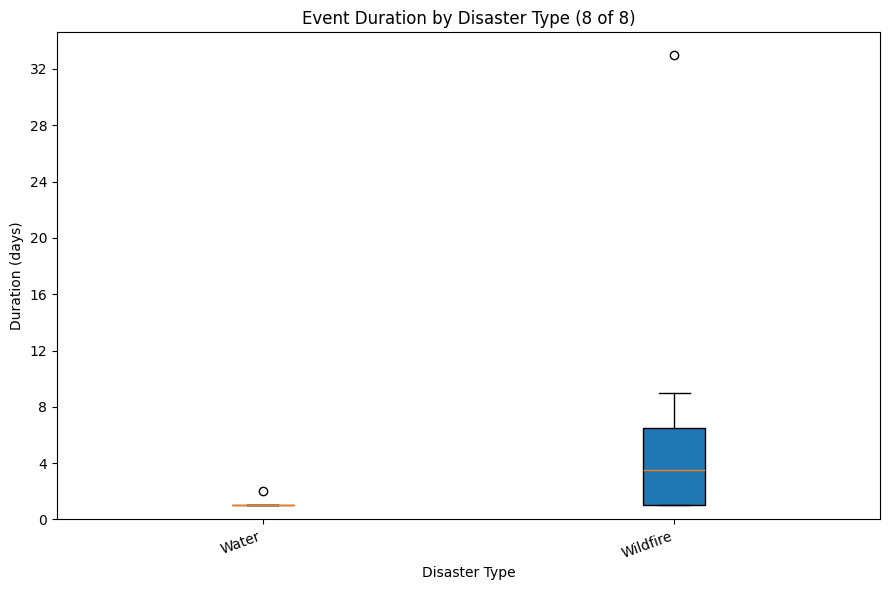


Outliers per Disaster Type (IQR method):

  Air: no outliers

  Collapse (Industrial): no outliers

  Collapse (Miscellaneous): no outliers

  Drought: no outliers

  Earthquake  (Q1=1, Q3=1, IQR=0, fence=[1, 1])
  1 outlier(s): [54.0]

  Epidemic  (Q1=18, Q3=88, IQR=70, fence=[-86, 192])
  1 outlier(s): [218.0]

  Explosion (Industrial): no outliers

  Explosion (Miscellaneous): no outliers

  Extreme temperature: no outliers

  Fire (Industrial): no outliers

  Fire (Miscellaneous): no outliers

  Flood  (Q1=2, Q3=7, IQR=5, fence=[-6, 14])
  18 outlier(s): [16.0, 19.0, 19.0, 19.0, 24.0, 24.0, 28.0, 29.0, 30.0, 37.0, 39.0, 48.0, 48.0, 62.0, 74.0, 74.0, 87.0, 112.0]

  Gas leak: no outliers

  Glacial lake outburst flood: no outliers

  Industrial accident (General): no outliers

  Mass movement (wet)  (Q1=1, Q3=1, IQR=0, fence=[1, 1])
  4 outlier(s): [2.0, 2.0, 4.0, 5.0]

  Miscellaneous accident (General)  (Q1=1, Q3=1, IQR=0, fence=[1, 1])
  1 outlier(s): [2.0]

  Rail: no outliers


In [6]:

# --- Box plots of event duration by Disaster Type (3 per chart) ---
import matplotlib.ticker as mticker

duration_data = df.dropna(subset=['_duration'])
disaster_types = sorted(duration_data['Disaster Type'].dropna().unique())

# Group into chunks of 3 so each chart stays readable
chunk_size = 3
chunks = [disaster_types[i:i + chunk_size] for i in range(0, len(disaster_types), chunk_size)]

for i, chunk in enumerate(chunks, start=1):
    grouped_durations = [
        duration_data.loc[duration_data['Disaster Type'] == dt, '_duration'].values
        for dt in chunk
    ]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.boxplot(grouped_durations, tick_labels=chunk, patch_artist=True, vert=True)
    ax.set_title(f'Event Duration by Disaster Type ({i} of {len(chunks)})')
    ax.set_xlabel('Disaster Type')
    ax.set_ylabel('Duration (days)')
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

# --- Print IQR outliers per Disaster Type ---
# An outlier is any value below Q1 - 1.5*IQR  or above  Q3 + 1.5*IQR
print("\nOutliers per Disaster Type (IQR method):")
print("=" * 60)

for dt in disaster_types:
    group = duration_data.loc[duration_data['Disaster Type'] == dt, '_duration']
    q1, q3 = group.quantile(0.25), group.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = group[(group < lower) | (group > upper)]
    if outliers.empty:
        print(f"\n  {dt}: no outliers")
    else:
        print(f"\n  {dt}  (Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f},"
              f" fence=[{lower:.0f}, {upper:.0f}])")
        print(f"  {len(outliers)} outlier(s): {sorted(outliers.tolist())}")


## 5. Outlier Investigation & Fix
Two duration outliers are identified and investigated:

In [ ]:
# After manually examining the raw data file i discovered that the Earthquake 
# in Iceland from Oct 25 to Dec 18 (54 days) is a significant outlier.
# Upon looking this up , i discovered this recording is most likely referring to the
# 2023 Iceland earthquake sequence, which indeed started on Oct 25 and had significant 
# seismic activity for weeks. It did experience a period of nearly continuous
# seismic activity that lasted for roughly two months.
# However according to the Quakealerts (USGS), the mainshock on Oct 25 lasted only about 1 minute,
# and was the most significant event in the sequence. With a rating of 4.6.
# Considering all this , im going to update the start and end dates for this event to Oct 25 setting it to a
# duration of 1 day, which is more in line with the mainshock event that is being recorded here.

# Source: https://www.sms-tsunami-warning.com/earthquakes-today/us7000l66j/Vogar-Iceland/25-10-2023
# Source:https://www.volcanodiscovery.com/earthquakes/quake-info/7961877/mag3quake-Oct-25-2023-Iceland-34-km-N-of-Grindavik.html

print("--- Earthquake Outlier: Iceland ---")
display(natural_disasters_clean[
    (natural_disasters_clean['Disaster Type'] == 'Earthquake') &
    (natural_disasters_clean['Country'] == 'Iceland') &
    (natural_disasters_clean['Start Month'] == 10) &
    (natural_disasters_clean['Start Day'] == 25)
])

# The outlier for epidemic was for Somalia, caused by a Cholera surge lasting ~3 months.
# This is plausible and will be retained as a valid record.
print("\n--- Epidemic Outlier: Somalia (Cholera) ---")
display(natural_disasters_clean[
    (natural_disasters_clean['Disaster Type'] == 'Epidemic') &
    (natural_disasters_clean['Country'] == 'Somalia') &
    (natural_disasters_clean['Start Month'] == 1) &
    (natural_disasters_clean['Start Day'] == 1)
])

# From what i have seen all these outliers are valid and have a real world explanation, 
# so i will not be removing any of them from the dataset.

--- Earthquake Outlier: Iceland ---


,Disaster Type,Country,Start Month,Start Day,End Month,End Day,Total Affected,No. Injured,No. Affected,No. Homeless
418,Earthquake,Iceland,10.0,25.0,12.0,18.0,3665.0,NaN,3665.0,NaN



--- Epidemic Outlier: Somalia (Cholera) ---


,Disaster Type,Country,Start Month,Start Day,End Month,End Day,Total Affected,No. Injured,No. Affected,No. Homeless
19,Epidemic,Somalia,1.0,1.0,4.0,4.0,3428.0,3428.0,NaN,NaN


## 6. Date Imputation
Missing date fields are imputed using the median duration per disaster type. Partial dates (one end known) are derived via timedelta arithmetic; fully absent dates fall back to the mode start month for the disaster type.

In [8]:
median_duration = (
    df.groupby('Disaster Type')['_duration']
    .median()
    .round()
    .clip(lower=1)
    .astype(int)
    .to_dict()
)

print("\nMedian duration (days) per Disaster Type (after capping):")
for k, v in median_duration.items():
    print(f"  {k}: {v} days")


Median duration (days) per Disaster Type (after capping):
  Air: 1 days
  Collapse (Industrial): 1 days
  Collapse (Miscellaneous): 1 days
  Drought: 305 days
  Earthquake: 1 days
  Epidemic: 45 days
  Explosion (Industrial): 1 days
  Explosion (Miscellaneous): 1 days
  Extreme temperature: 6 days
  Fire (Industrial): 1 days
  Fire (Miscellaneous): 1 days
  Flood: 4 days
  Gas leak: 1 days
  Glacial lake outburst flood: 1 days
  Industrial accident (General): 1 days
  Mass movement (wet): 1 days
  Miscellaneous accident (General): 1 days
  Rail: 1 days
  Road: 1 days
  Storm: 2 days
  Volcanic activity: 1 days
  Water: 1 days
  Wildfire: 4 days


In [9]:

# --- Impute missing Start Day / End Day ---
# - Adding days past the end of a month rolls forward into the next month.
# - Subtracting days past the 1st of a month rolls back into the previous month.

def impute_partial_dates(row):
  
    # If a start or end date is missing I estimate it by using the median length of that specific type of disaster.

    # Start missing, End present     start = end  - median_duration days
    # Start present, End missing     end   = start + median_duration days

    sm, sd = row['Start Month'], row['Start Day']
    em, ed = row['End Month'],   row['End Day']
    dtype  = row['Disaster Type']

    # Lookup the median duration for this Disaster Type, fall back to 1 day
    med_days = median_duration.get(dtype, 1)

    has_start = pd.notna(sm) and pd.notna(sd)
    has_end   = pd.notna(em) and pd.notna(ed)


    if has_start and has_end:
        return sm, sd, em, ed

    # Case A – derive start from end date
    if (not has_start) and has_end:
        end_dt = safe_date(em, ed)
        if end_dt is not None:
            # timedelta subtraction: date rolls back across month boundaries
            start_dt = end_dt - timedelta(days=med_days)
            return float(start_dt.month), float(start_dt.day), em, ed

    # Case B – derive end from start date
    if has_start and (not has_end):
        start_dt = safe_date(sm, sd)
        if start_dt is not None:
            # timedelta addition: date rolls forward across month boundaries
            end_dt = start_dt + timedelta(days=med_days)
            return sm, sd, float(end_dt.month), float(end_dt.day)

    # If both are missing , i handle it later on
    return sm, sd, em, ed

imputed_partial = df.apply(
    impute_partial_dates, axis=1, result_type='expand'
)
imputed_partial.columns = ['Start Month', 'Start Day', 'End Month', 'End Day']
df[['Start Month', 'Start Day', 'End Month', 'End Day']] = imputed_partial

print("After partial-date imputation:")
print(f"  Start Day missing : {df['Start Day'].isna().sum()}")
print(f"  End Day missing   : {df['End Day'].isna().sum()}")


After partial-date imputation:
  Start Day missing : 62
  End Day missing   : 62


In [10]:

# --- Impute rows where BOTH Month and Day are still missing ---

# Strategy:

#   Ill get the start date like so:
#   Month = mode month for that Disaster Type.
#   Day   = set to the middle day , 15th .

#   For End Month/Day I will offset Start by the median duration for that Disaster Type,


# Mode month per Disaster Type, derived from known Start Month values only
mode_month = (
    df.dropna(subset=['Start Month'])
    .groupby('Disaster Type')['Start Month']
    .agg(lambda x: x.mode().iloc[0])  
    .to_dict()
)

# Used if an entire Disaster Type has no known Start Month
global_mode_month = float(df['Start Month'].dropna().mode().iloc[0])

def fill_total_loss(row):
    sm, sd = row['Start Month'], row['Start Day']
    em, ed = row['End Month'],   row['End Day']
    dtype  = row['Disaster Type']

    # Fill Start if either component is missing
    if pd.isna(sm) or pd.isna(sd):
        sm = float(mode_month.get(dtype, global_mode_month))
        sd = 15.0  # day = 15: set tp mid-month 

    # Derive End from Start + median duration if End is absent
    if pd.isna(em) or pd.isna(ed):
        med_days = median_duration.get(dtype, 1)
        start_dt = safe_date(sm, sd)
        if start_dt is not None:
            end_dt = start_dt + timedelta(days=med_days)
            em = float(end_dt.month)
            ed = float(end_dt.day)
        else:
            em = sm
            ed = sd

    return sm, sd, em, ed

imputed_total_loss = df.apply(fill_total_loss, axis=1, result_type='expand')
imputed_total_loss.columns = ['Start Month', 'Start Day', 'End Month', 'End Day']
df[['Start Month', 'Start Day', 'End Month', 'End Day']] = imputed_total_loss

print("After total-loss imputation:")
print(f"  Start Month missing : {df['Start Month'].isna().sum()}")
print(f"  Start Day missing   : {df['Start Day'].isna().sum()}")
print(f"  End Month missing   : {df['End Month'].isna().sum()}")
print(f"  End Day missing     : {df['End Day'].isna().sum()}")


After total-loss imputation:
  Start Month missing : 0
  Start Day missing   : 0
  End Month missing   : 0
  End Day missing     : 0


## 7. Impact Column Imputation
Missing values in `No. Affected`, `No. Injured`, `No. Homeless`, and `Total Affected` are filled using7
 mathematical calculations. 

In [11]:

# --- Fill remaining Total Affected NaNs from component columns ---
# If Total Affected is still missing, derive it as the sum of
# No. Injured, No. Affected, and No. Homeless (treating NaN components as 0).
# According to the dataset documentation, Total Affected 
# is the sum of these three components. If there is a NaN value
# I there are any NaN values in any of the three components I will assume
# that the value is 0 and that no one was made homeless or injured or affected.
# source: https://doc.emdat.be/docs/data-structure-and-content/emdat-public-table/

ta_missing_mask = df['Total Affected'].isna()

df.loc[ta_missing_mask, 'Total Affected'] = (
    df.loc[ta_missing_mask, ['No. Injured', 'No. Affected', 'No. Homeless']]
    .fillna(0)
    .sum(axis=1)
)

# Fill any remaining NaNs in the component columns with 0
for col in ['No. Injured', 'No. Affected', 'No. Homeless']:
    df[col] = df[col].fillna(0)

print("After Total Affected fill-from-components:")
for col in ['No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected']:
    print(f"  {col} missing: {df[col].isna().sum()}")


After Total Affected fill-from-components:
  No. Injured missing: 0
  No. Affected missing: 0
  No. Homeless missing: 0
  Total Affected missing: 0


## 8. Finalise Dataset
Helper columns are dropped, the cleaned dataframe is written back to `natural_disasters_clean`, and a final NaN summary confirms no residual missing values remain.

In [12]:

# ---  Drop helper columns and write back ---
df.drop(columns=['_start_date', '_end_date', '_duration'], inplace=True)
natural_disasters_clean = df

# Final validation: confirm no NaN values in any column
print("Final missing value summary:")
print("-" * 40)
for col in natural_disasters_clean.columns:
    n = natural_disasters_clean[col].isna().sum()
    print(f"  {col:25s}: {n} NaN")



Final missing value summary:
----------------------------------------
  Disaster Type            : 0 NaN
  Country                  : 0 NaN
  Start Month              : 0 NaN
  Start Day                : 0 NaN
  End Month                : 0 NaN
  End Day                  : 0 NaN
  Total Affected           : 0 NaN
  No. Injured              : 0 NaN
  No. Affected             : 0 NaN
  No. Homeless             : 0 NaN


## 9. Feature Engineering
New columns are derived from the cleaned data: `Disaster Type` is collapsed into broad categories and `Severity` 
classifies `Total Affected` into four bands.

In [13]:
# Rename Disaster Type values to their generic category
disaster_category_map = {
    # Natural
    'Earthquake':                    'Natural',
    'Volcanic activity':             'Natural',
    'Flood':                         'Natural',
    'Mass movement (wet)':           'Natural',
    'Glacial lake outburst flood':   'Natural',
    'Storm':                         'Natural',
    'Extreme temperature':           'Natural',
    'Drought':                       'Natural',
    'Wildfire':                      'Natural',
    'Epidemic':                      'Natural',
    # Industrial
    'Explosion (Industrial)':        'Industrial',
    'Fire (Industrial)':             'Industrial',
    'Collapse (Industrial)':         'Industrial',
    'Gas leak':                      'Industrial',
    'Industrial accident (General)': 'Industrial',
    # Transport
    'Rail':                          'Transport',
    'Road':                          'Transport',
    'Air':                           'Transport',
    'Water':                         'Transport',
    # Misc/Other
    'Explosion (Miscellaneous)':        'Misc/Other',
    'Fire (Miscellaneous)':             'Misc/Other',
    'Collapse (Miscellaneous)':         'Misc/Other',
    'Miscellaneous accident (General)': 'Misc/Other',
}

natural_disasters_clean['Disaster Type'] = natural_disasters_clean['Disaster Type'].map(disaster_category_map)
print("Disaster Type unique values after renaming:")
print(natural_disasters_clean['Disaster Type'].unique())

Disaster Type unique values after renaming:
<StringArray>
['Natural', 'Transport', 'Misc/Other', 'Industrial']
Length: 4, dtype: str


In [14]:

# --- Add Severity column ---
# Classifies Total Affected into informal severity levels used in practice:
#   None:          0 (no recorded impact)
#   Small-scale:   1 – 999
#   Medium-scale:  1,000 – 9,999
#   Large-scale:   10,000+

def classify_severity(total_affected):
    if total_affected == 0:
        return 'None'
    elif total_affected < 1_000:
        return 'Small-scale'
    elif total_affected < 10_000:
        return 'Medium-scale'
    else:
        return 'Large-scale'

natural_disasters_clean['Severity'] = natural_disasters_clean['Total Affected'].apply(classify_severity)

print("Severity level distribution:")
print(natural_disasters_clean['Severity'].value_counts())


Severity level distribution:
Severity
Small-scale     190
None            168
Large-scale     162
Medium-scale     92
Name: count, dtype: int64


## 10. Dataset Preview before creating new columns
The final columns are selected and the first 10 rows of the cleaned, engineered dataset are displayed.

In [15]:
# Select only the final columns needed for analysis
final_cols = ['Disaster Type', 'Country', 'Start Month', 'Start Day', 'End Month', 'End Day', 'Severity']
natural_disasters_clean = natural_disasters_clean[final_cols].copy()
natural_disasters_clean.head(10)

,Disaster Type,Country,Start Month,Start Day,End Month,End Day,Severity
0,Natural,Democratic Republic of the Congo,4.0,2.0,4.0,2.0,None
1,Natural,Angola,11.0,30.0,12.0,5.0,Large-scale
2,Natural,Thailand,12.0,22.0,12.0,25.0,Large-scale
3,Natural,Democratic Republic of the Congo,12.0,26.0,12.0,27.0,Small-scale
4,Natural,France,12.0,30.0,1.0,3.0,Medium-scale
5,Natural,India,12.0,18.0,12.0,20.0,None
6,Natural,Malaysia,12.0,22.0,12.0,25.0,Large-scale
7,Natural,South Africa,12.0,24.0,12.0,26.0,Medium-scale
8,Natural,Congo,12.0,7.0,1.0,15.0,Large-scale
9,Transport,Greece,3.0,1.0,3.0,1.0,Small-scale


In [16]:
numeric_cols = [ 'Start Month', 'Start Day', 'End Month', 'End Day','Severity']
# Statistical summary of the fully cleaned dataset.
print("Statistical Summary:")
print(natural_disasters_clean[numeric_cols].describe().round(2).to_string())


Statistical Summary:
       Start Month  Start Day  End Month  End Day
count       612.00     612.00     612.00   612.00
mean          6.30      14.92       6.62    15.96
std           3.45       8.61       3.37     8.75
min           1.00       1.00       1.00     1.00
25%           3.00       7.00       3.00     8.00
50%           7.00      15.00       7.00    17.00
75%           9.00      22.00       9.00    23.00
max          12.00      31.00      12.00    31.00


In [17]:
# Final confirmation that the dataset is fully clean and ready for analysis.
print("Final Dataset Info:")
print("-" * 40)
natural_disasters_clean.info()


Final Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Disaster Type  612 non-null    str    
 1   Country        612 non-null    str    
 2   Start Month    612 non-null    float64
 3   Start Day      612 non-null    float64
 4   End Month      612 non-null    float64
 5   End Day        612 non-null    float64
 6   Severity       612 non-null    str    
dtypes: float64(4), str(3)
memory usage: 33.6 KB


## 11. National Disaster Profile per Country

Some Countries can have multiple disasters in the same year.
Each country is reduced to a single-row **National Disaster Profile** containing:

| Column | Description |
|---|---|
| `Country` | Country name |
| `Disaster_Count` | Total number of individual disaster events |
| `Median_Severity` | Typical severity across all events (0–1 scale) — resistant to skew |
| `Unique_Days_Under_Threat` | Distinct calendar days with ≥ 1 active disaster, capped at 365 |


In [18]:

# --- Build a working copy with proper date objects 

profile_df = natural_disasters_clean.copy()

profile_df['Start_Date'] = profile_df.apply(
    lambda r: safe_date(r['Start Month'], r['Start Day']), axis=1
)
profile_df['End_Date'] = profile_df.apply(
    lambda r: safe_date(r['End Month'], r['End Day']), axis=1
)

# --- Map categorical Severity to a 0–1 numeric scale 
SEVERITY_MAP = {
    'None':         0.00,   # 0 affected
    'Small-scale':  0.25,   # 1 – 999
    'Medium-scale': 0.50,   # 1 000 – 9 999
    'Large-scale':  1.00,   # 10 000+
}
profile_df['Severity_Num'] = profile_df['Severity'].map(SEVERITY_MAP)


In [19]:

# --- Unique Days a country was affected by disasters 
def _unique_days_under_threat(group):
    occupied = set()
    for _, row in group.iterrows():
        s, e = row['Start_Date'], row['End_Date']
        if s is None or e is None:
            continue
        e = min(e, YEAR_END)
        if s > YEAR_END:
            continue
        occupied.update(range(s.toordinal(), e.toordinal() + 1))
    return min(len(occupied), 365)

unique_days_series = (
    profile_df[['Country', 'Start_Date', 'End_Date']]
    .groupby('Country')
    .apply(_unique_days_under_threat)
    .rename('Unique_Days_Under_Threat')
)

# --- Aggregate and assemble 
national_profile = (
    profile_df
    .groupby('Country')
    .agg(
        Disaster_Count   = ('Country',      'count'),
        Median_Severity  = ('Severity_Num', 'median'),
    )
    .join(unique_days_series)
    .reset_index()
)

national_profile['Median_Severity'] = national_profile['Median_Severity'].round(4)

print(f"National Disaster Profile: {len(national_profile)} countries")
national_profile.sort_values('Unique_Days_Under_Threat', ascending=False).head(10)


National Disaster Profile: 156 countries


,Country,Disaster_Count,Median_Severity,Unique_Days_Under_Threat
27,China,29,0.250,365
13,Bolivia (Plurinational State of),6,0.500,316
63,Indonesia,18,0.500,315
148,Uruguay,3,0.500,314
76,Lesotho,2,0.625,313
95,Mozambique,4,1.000,312
16,Brazil,18,0.500,311
59,Honduras,4,0.625,307
91,Micronesia (Federated States of),1,1.000,306
67,Italy,13,0.000,306


## 12. National Disaster Profile Preview
Statistical summary and a final info check of the national disaster profile dataset.

In [20]:
numeric_cols = ['Disaster_Count', 'Median_Severity', 'Unique_Days_Under_Threat']
# Statistical summary of the fully cleaned dataset.
print("Statistical Summary:")
print(national_profile[numeric_cols].describe().round(2).to_string())


Statistical Summary:
       Disaster_Count  Median_Severity  Unique_Days_Under_Threat
count          156.00           156.00                    156.00
mean             3.92             0.40                     48.21
std              4.72             0.34                     88.04
min              1.00             0.00                      1.00
25%              1.00             0.25                      5.00
50%              2.00             0.25                     11.00
75%              5.00             0.50                     46.00
max             29.00             1.00                    365.00


In [21]:
# Final confirmation that the dataset is fully clean and ready for analysis.
print("Final Dataset Info:")
print("-" * 40)
national_profile.info()


Final Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   156 non-null    str    
 1   Disaster_Count            156 non-null    int64  
 2   Median_Severity           156 non-null    float64
 3   Unique_Days_Under_Threat  156 non-null    int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 5.0 KB


In [22]:
national_profile = national_profile.rename(columns={'Country': 'country'})
national_profile.to_csv('../Cleaned_Csvs/Cleaned_Natural_Disasters.csv', index=False)
print("Saved to Cleaned_Csvs/Cleaned_Natural_Disasters.csv")


Saved to Cleaned_Csvs/Cleaned_Natural_Disasters.csv


## 13. Multivariate Assessment for Index Integration

This section evaluates the risk variables (disaster metrics) to assess their readiness for inclusion in the composite "Best Country to Visit" index. Special attention is given to the interpretation of multicollinearity and domain relevance.


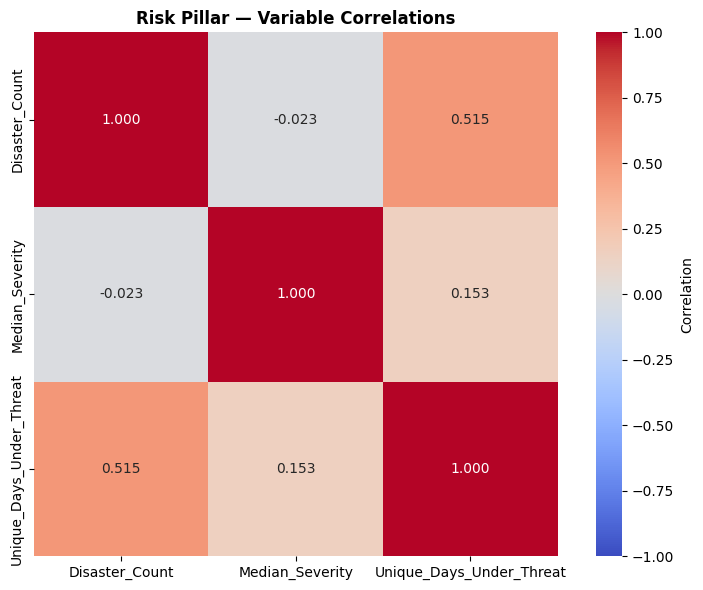

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns to assess
numeric_cols = ['Disaster_Count', 'Median_Severity', 'Unique_Days_Under_Threat']
risk_data = national_profile[numeric_cols]

# Correlation heatmap
corr_matrix = risk_data.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Risk Pillar — Variable Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Data Source

This dataset is sourced from EM-DAT (CRED), a global disaster database that records country-level disaster events and impacts. It is used here to derive risk exposure features for the holiday index.

Source: https://www.emdat.be/

## 15. References

Centre for Research on the Epidemiology of Disasters (CRED) (2024) *EM-DAT Public Table — Data Structure and Content*. Available at: [https://doc.emdat.be/docs/data-structure-and-content/emdat-public-table/](https://doc.emdat.be/docs/data-structure-and-content/emdat-public-table/) (Accessed: 17 April 2026).

SMS Tsunami Warning (2023) *Earthquake us7000l66j — Vogar, Iceland, 25 October 2023*. Available at: [https://www.sms-tsunami-warning.com/earthquakes-today/us7000l66j/Vogar-Iceland/25-10-2023](https://www.sms-tsunami-warning.com/earthquakes-today/us7000l66j/Vogar-Iceland/25-10-2023) (Accessed: 17 April 2026).

VolcanoDiscovery (2023) *Magnitude 3 earthquake — 34 km N of Grindavik, Iceland, 25 October 2023*. Available at: [https://www.volcanodiscovery.com/earthquakes/quake-info/7961877/mag3quake-Oct-25-2023-Iceland-34-km-N-of-Grindavik.html](https://www.volcanodiscovery.com/earthquakes/quake-info/7961877/mag3quake-Oct-25-2023-Iceland-34-km-N-of-Grindavik.html) (Accessed: 17 April 2026).